# 📰 การตรวจสอบข่าวปลอมด้วย Deep Learning และ NLP
## Fake News Detection - Thai Twitter Dataset

**วิชา:** Deep Learning & NLP  
**อ้างอิง:** วิทยานิพนธ์ ดร.สุปัญญา อภิวงศ์โสภณ (จุฬาฯ, 2561)

### โมเดลที่ใช้เปรียบเทียบ
| ระดับ | โมเดล |
|-------|-------|
| Baseline | Naïve Bayes, SVM (TF-IDF) |
| Deep Learning | LSTM, BiLSTM |
| Transformer | WangchanBERTa (BERT ภาษาไทย) |

## 📚 Cell 1: Import Library

In [31]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Thai font สำหรับ matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# NLP
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

# Scikit-learn (Baseline)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Transformers (HuggingFace)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset as HFDataset

# Set seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
print('✅ Import Library เรียบร้อย')

🖥️  Device: cpu
✅ Import Library เรียบร้อย


## 📂 Cell 3: โหลด Dataset จาก HuggingFace

ใช้ Dataset ภาษาไทยจาก HuggingFace:
- **`thai_nner`** หรือ Dataset ข่าวไทยที่มี label จริง/ปลอม
- หากไม่มี Dataset ไทยโดยตรง จะสร้าง **Synthetic Dataset** จำลองโครงสร้างเดียวกับวิทยานิพนธ์

In [32]:
from datasets import load_dataset

# ============================================================
# ตัวเลือก 1: โหลดจาก HuggingFace (ถ้ามี Dataset ภาษาไทย)
# ============================================================
USE_REAL_DATASET = False  # เปลี่ยนเป็น True ถ้ามี dataset จริง

DATASET_OPTIONS = {
    'thai_fake_news': 'pythainlp/thai-fake-news',      # ถ้ามีบน HuggingFace
    'liar': 'liar',                                     # LIAR dataset (อังกฤษ)
    'fake_news_thai': 'Woramet/thai-fake-news-dataset', # ตัวอย่างชื่อ
}

# ============================================================
# ตัวเลือก 2: สร้าง Synthetic Dataset (โครงสร้างเดียวกับวิทยานิพนธ์)
# จำลองข้อมูล Twitter ภาษาไทย พร้อม features ตามที่วิทยานิพนธ์ใช้
# ============================================================

def create_thai_twitter_dataset(n_samples=2000, fake_ratio=0.3):
    """
    สร้าง Synthetic Dataset จำลองข้อมูล Twitter ภาษาไทย
    โครงสร้างตามวิทยานิพนธ์ ดร.สุปัญญา อภิวงศ์โสภณ
    """
    np.random.seed(SEED)
    n_fake = int(n_samples * fake_ratio)
    n_real = n_samples - n_fake

    # ========== ข่าวจริง (Real News) ==========
    real_templates = [
        'กรมอุตุนิยมวิทยาประกาศเตือนภัยพายุ {} ในภาค {} คาดว่าจะมีฝนตกหนัก',
        'ธนาคารแห่งประเทศไทยรายงานอัตราดอกเบี้ยนโยบายอยู่ที่ {} เปอร์เซ็นต์',
        'รัฐบาลประกาศมาตรการช่วยเหลือเกษตรกรผู้ประสบภัยแล้งในพื้นที่ {}',
        'กระทรวงสาธารณสุขยืนยันพบผู้ป่วยโรค {} จำนวน {} ราย',
        'สำนักงานตำรวจแห่งชาติแถลงข่าวจับกุมผู้ต้องสงสัยคดี {} ได้แล้ว',
        'มหาวิทยาลัย {} เปิดรับสมัครนักศึกษาใหม่ปีการศึกษา {} จำนวน {} คน',
        'กระทรวงพาณิชย์เผยดัชนีราคาผู้บริโภคเดือนนี้อยู่ที่ {} เปอร์เซ็นต์',
        'สภาผู้แทนราษฎรลงมติเห็นชอบร่างพระราชบัญญัติ {} ด้วยคะแนน {} ต่อ {}',
        'การรถไฟแห่งประเทศไทยประกาศเพิ่มขบวนรถพิเศษช่วงเทศกาล {} รวม {} ขบวน',
        'กรุงเทพมหานครเปิดโครงการ {} ช่วยเหลือประชาชนในพื้นที่ {} เขต',
        'ทีมชาติไทยชนะการแข่งขัน {} ด้วยคะแนน {} ต่อ {} คะแนน',
        'สำนักงานคณะกรรมการอาหารและยาอนุมัติยา {} สำหรับรักษาโรค {}',
    ]
    real_fillers = [
        ['ดีเปรสชัน', 'เหนือ', '3.5', 'ภาคใต้', 'ยาเสพติด', 'จุฬาฯ', '2567',
         '3500', 'ไวรัส', '120', 'งบประมาณ', '250', '180', 'สงกรานต์', '20',
         'ฟุตบอล', '3', '1', 'ไทยบริดจ์', 'มะเร็ง']
    ]

    # ========== ข่าวปลอม (Fake News) ==========
    fake_templates = [
        'ด่วน!! {} ยืนยันแล้ว อย่าลืมแชร์ให้คนในครอบครัวรู้ด้วย!!!',
        'เปิดเผยความจริง! รัฐบาลซ่อนข้อมูลเรื่อง {} มาหลายปีแล้ว',
        'แพทย์ต่างประเทศยืนยัน {} รักษาโรค {} ได้ 100% ผลพิสูจน์แล้ว!',
        'BREAKING: {} ถูกพบว่ามีสารพิษ ห้ามใช้เด็ดขาด แชร์ด่วน!!',
        'ความลับที่รัฐบาลไม่อยากให้รู้! {} จริงๆ แล้วคือ {}',
        'อย่าเชื่อสื่อกระแสหลัก! ความจริงเรื่อง {} คือสิ่งที่พวกเขาปิดบังคุณ',
        'ปาฏิหาริย์!! {} สามารถ {} ได้ภายใน 3 วัน ไม่ต้องพึ่งยา',
        'เตือนภัยด่วน! {} จะเกิดขึ้นในวันที่ {} อย่าออกจากบ้าน!!',
        'ข่าวที่ CNN และ BBC ไม่กล้าเผยแพร่ เรื่อง {} ที่ทำให้โลกตกใจ',
        'หมอเผยความลับ! กินแค่ {} ทุกวัน หายป่วย {} ภายในสัปดาห์เดียว',
        'ระวัง!! {} ที่คุณใช้ทุกวันอาจทำให้ {} แพร่กระจายในร่างกาย',
        'แชร์ต่อด่วน! {} ยืนยันว่า {} เป็นเรื่องจริง อย่าให้ใครมาหลอก',
    ]

    words_pool = [
        'น้ำมะนาว', 'วัคซีน', 'รัฐบาล', 'นักวิทยาศาสตร์', 'เชื้อไวรัส',
        'สมุนไพร', 'น้ำผึ้ง', 'ขมิ้น', 'กัญชา', '5G', 'ไมโครชิพ', 'มะเร็ง',
        '10 มกราคม', 'แผ่นดินไหว', 'สึนามิ', 'เคมีในอาหาร', 'แบคทีเรีย'
    ]

    records = []

    # สร้างข่าวจริง
    for i in range(n_real):
        template = real_templates[i % len(real_templates)]
        filler = words_pool[:template.count('{}')]
        try:
            text = template.format(*filler)
        except Exception:
            text = template.replace('{}', 'ข้อมูลจริง')

        records.append({
            'text': text,
            'label': 0,  # 0 = Real
            'label_name': 'real',
            # Twitter user features (ตามวิทยานิพนธ์)
            'followers_count': np.random.randint(100, 50000),
            'friends_count': np.random.randint(50, 5000),
            'statuses_count': np.random.randint(100, 10000),
            'is_verified': np.random.choice([0, 1], p=[0.7, 0.3]),
            'has_profile_image': 1,
            'has_description': np.random.choice([0, 1], p=[0.2, 0.8]),
            'retweet_count': np.random.randint(0, 500),
            'has_url': np.random.choice([0, 1], p=[0.3, 0.7]),
            'num_hashtags': np.random.randint(0, 3),
            'num_mentions': np.random.randint(0, 2),
        })

    # สร้างข่าวปลอม
    for i in range(n_fake):
        template = fake_templates[i % len(fake_templates)]
        filler = words_pool[:template.count('{}')]
        try:
            text = template.format(*filler)
        except Exception:
            text = template.replace('{}', 'ข่าวลวง')

        records.append({
            'text': text,
            'label': 1,  # 1 = Fake
            'label_name': 'fake',
            # Fake accounts มักมี features แตกต่าง
            'followers_count': np.random.randint(0, 200),
            'friends_count': np.random.randint(0, 1000),
            'statuses_count': np.random.randint(1, 500),
            'is_verified': 0,
            'has_profile_image': np.random.choice([0, 1], p=[0.4, 0.6]),
            'has_description': np.random.choice([0, 1], p=[0.5, 0.5]),
            'retweet_count': np.random.randint(0, 5000),
            'has_url': np.random.choice([0, 1], p=[0.6, 0.4]),
            'num_hashtags': np.random.randint(2, 8),
            'num_mentions': np.random.randint(0, 5),
        })

    df = pd.DataFrame(records)
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


# สร้าง Dataset
df = create_thai_twitter_dataset(n_samples=2000, fake_ratio=0.3)

print('📊 Dataset Overview:')
print(f'   Total samples: {len(df):,}')
print(f'   Real news  (0): {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print(f'   Fake news  (1): {(df.label==1).sum():,} ({(df.label==1).mean()*100:.1f}%)')
print()
df.head()

📊 Dataset Overview:
   Total samples: 2,000
   Real news  (0): 1,400 (70.0%)
   Fake news  (1): 600 (30.0%)



,text,label,label_name,followers_count,friends_count,statuses_count,is_verified,has_profile_image,has_description,retweet_count,has_url,num_hashtags,num_mentions
0,ความลับที่รัฐบาลไม่อยากให้รู้! น้ำมะนาว จริงๆ ...,1,fake,120,274,231,0,1,0,2239,0,3,1
1,มหาวิทยาลัย น้ำมะนาว เปิดรับสมัครนักศึกษาใหม่ป...,0,real,13082,1660,8225,1,1,1,202,1,2,1
2,ธนาคารแห่งประเทศไทยรายงานอัตราดอกเบี้ยนโยบายอย...,0,real,22047,3238,9385,0,1,1,131,1,2,0
3,มหาวิทยาลัย น้ำมะนาว เปิดรับสมัครนักศึกษาใหม่ป...,0,real,17840,1064,1154,1,1,0,309,1,2,0
4,มหาวิทยาลัย น้ำมะนาว เปิดรับสมัครนักศึกษาใหม่ป...,0,real,156,2293,5979,0,1,1,252,0,1,1


## 🔍 Cell 4: Exploratory Data Analysis (EDA)

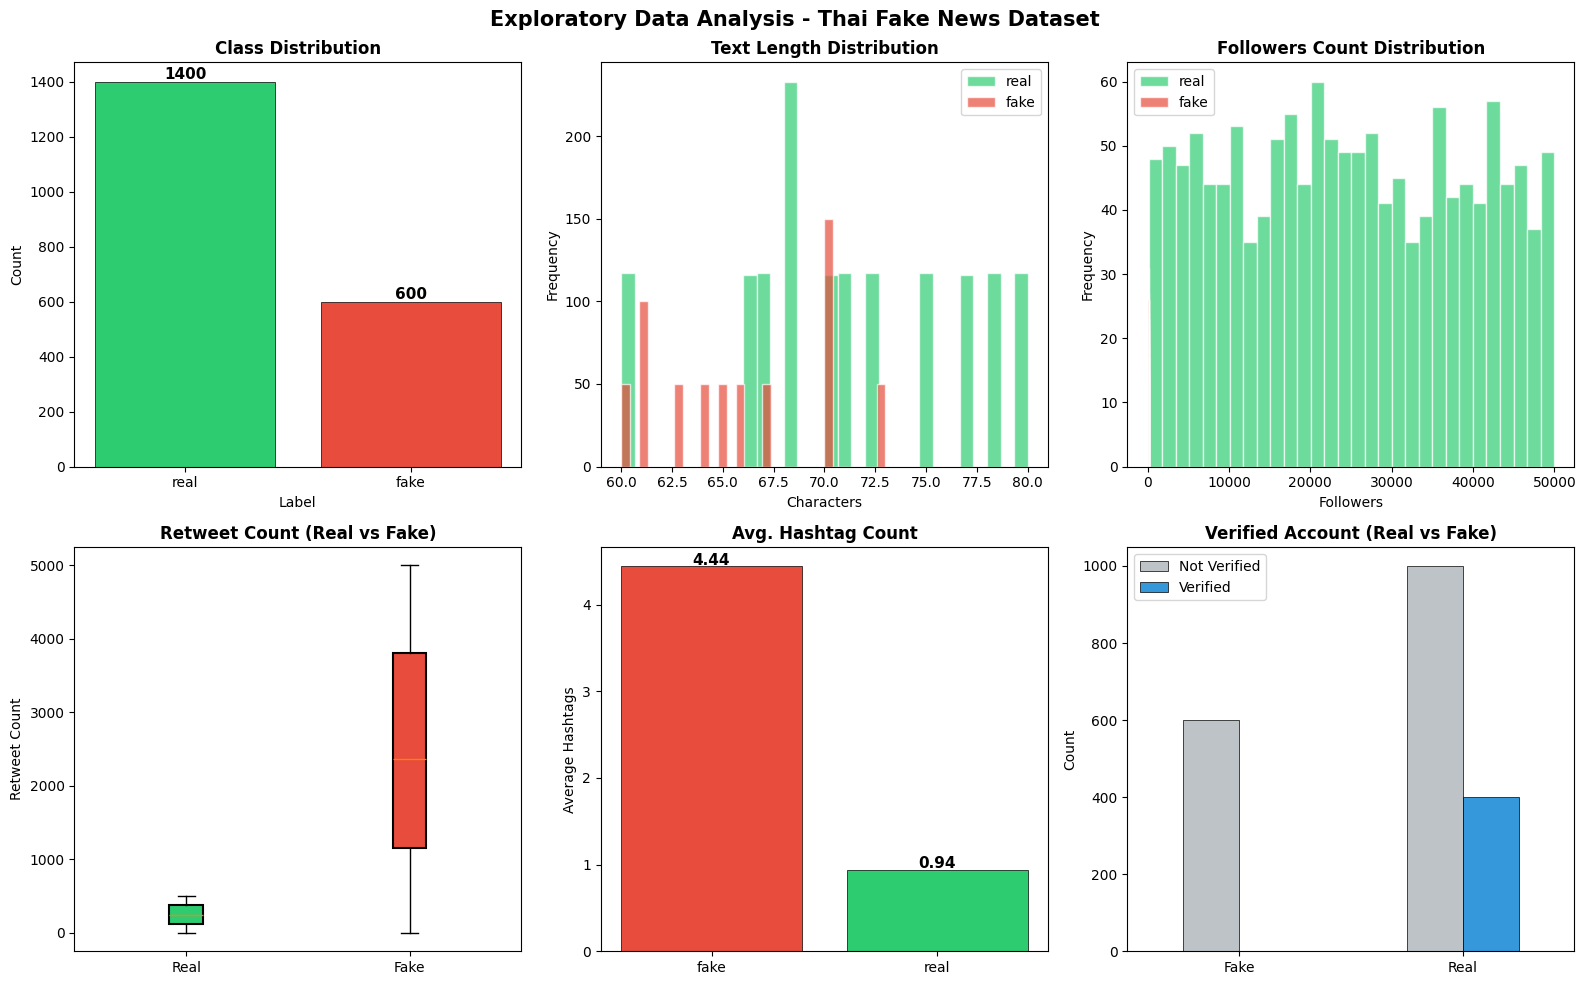

✅ EDA เสร็จสิ้น


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis - Thai Fake News Dataset', fontsize=15, fontweight='bold')

colors = {'real': '#2ecc71', 'fake': '#e74c3c'}

# 1. Class Distribution
ax1 = axes[0, 0]
counts = df['label_name'].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=[colors[l] for l in counts.index], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Label')

# 2. Text Length Distribution
ax2 = axes[0, 1]
df['text_length'] = df['text'].apply(len)
for label, color in [('real', '#2ecc71'), ('fake', '#e74c3c')]:
    data = df[df['label_name'] == label]['text_length']
    ax2.hist(data, bins=30, alpha=0.7, color=color, label=label, edgecolor='white')
ax2.set_title('Text Length Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Characters')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Followers Count
ax3 = axes[0, 2]
for label, color in [('real', '#2ecc71'), ('fake', '#e74c3c')]:
    data = df[df['label_name'] == label]['followers_count']
    ax3.hist(data, bins=30, alpha=0.7, color=color, label=label, edgecolor='white')
ax3.set_title('Followers Count Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Followers')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. Retweet Count
ax4 = axes[1, 0]
df_box = df[['label_name', 'retweet_count']]
real_rt = df[df['label_name']=='real']['retweet_count']
fake_rt = df[df['label_name']=='fake']['retweet_count']
bp = ax4.boxplot([real_rt, fake_rt], labels=['Real', 'Fake'],
                  patch_artist=True,
                  boxprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax4.set_title('Retweet Count (Real vs Fake)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Retweet Count')

# 5. Hashtag Count
ax5 = axes[1, 1]
hashtag_avg = df.groupby('label_name')['num_hashtags'].mean()
bars5 = ax5.bar(hashtag_avg.index, hashtag_avg.values,
                 color=[colors[l] for l in hashtag_avg.index],
                 edgecolor='black', linewidth=0.5)
for bar, val in zip(bars5, hashtag_avg.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax5.set_title('Avg. Hashtag Count', fontsize=12, fontweight='bold')
ax5.set_ylabel('Average Hashtags')

# 6. Verified Account
ax6 = axes[1, 2]
verified = df.groupby(['label_name', 'is_verified']).size().unstack(fill_value=0)
verified.plot(kind='bar', ax=ax6, color=['#bdc3c7', '#3498db'], edgecolor='black', linewidth=0.5)
ax6.set_title('Verified Account (Real vs Fake)', fontsize=12, fontweight='bold')
ax6.set_xlabel('')
ax6.set_xticklabels(['Fake', 'Real'], rotation=0)
ax6.set_ylabel('Count')
ax6.legend(['Not Verified', 'Verified'])

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA เสร็จสิ้น')

## 🔤 Cell 5: Text Preprocessing (ภาษาไทย)

In [34]:
import re
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

STOPWORDS = set(thai_stopwords())

def preprocess_thai(text: str, remove_stopwords: bool = True) -> str:
    """Preprocess ข้อความภาษาไทย"""
    # 1. ลบอักขระพิเศษ URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 2. ลบ mention และ hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # 3. ลบตัวเลขและอักขระพิเศษ (เก็บแค่ตัวอักษรไทย/อังกฤษ)
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z\s]', ' ', text)
    # 4. ลบช่องว่างซ้ำ
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Tokenize ภาษาไทย
    tokens = word_tokenize(text, engine='newmm')
    # 6. ลบ stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and t.strip()]
    return ' '.join(tokens)


print('🔄 กำลัง Preprocess ข้อความ...')
df['text_clean'] = df['text'].apply(preprocess_thai)
print('✅ Preprocess เสร็จสิ้น')

# ตัวอย่าง
print('\n📌 ตัวอย่าง:')
for i in range(3):
    print(f'  [{df.label_name[i].upper()}]')
    print(f'  Original: {df.text[i]}')
    print(f'  Cleaned : {df.text_clean[i]}')
    print()

🔄 กำลัง Preprocess ข้อความ...
✅ Preprocess เสร็จสิ้น

📌 ตัวอย่าง:
  [FAKE]
  Original: ความลับที่รัฐบาลไม่อยากให้รู้! น้ำมะนาว จริงๆ แล้วคือ วัคซีน
  Cleaned : ความลับ รัฐบาล รู้ น้ำ มะนาว วัคซีน

  [REAL]
  Original: มหาวิทยาลัย น้ำมะนาว เปิดรับสมัครนักศึกษาใหม่ปีการศึกษา วัคซีน จำนวน รัฐบาล คน
  Cleaned : มหาวิทยาลัย น้ำ มะนาว รับสมัคร นักศึกษา ปีการศึกษา วัคซีน จำนวน รัฐบาล คน

  [REAL]
  Original: ธนาคารแห่งประเทศไทยรายงานอัตราดอกเบี้ยนโยบายอยู่ที่ น้ำมะนาว เปอร์เซ็นต์
  Cleaned : ธนาคารแห่งประเทศไทย รายงาน อัตราดอกเบี้ย นโยบาย น้ำ มะนาว เปอร์เซ็นต์



## ✂️ Cell 6: Train/Validation/Test Split

In [35]:
X = np.array(df['text_clean'].tolist())
X_raw = np.array(df['text'].tolist())  # สำหรับ BERT
y = np.array(df['label'].tolist())

# แบ่ง 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# สำหรับ BERT (raw text)
X_train_raw, X_temp_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.30, random_state=SEED, stratify=y)
X_val_raw, X_test_raw, _, _ = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print('📊 Dataset Split:')
print(f'   Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Val   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.0f}%)')
print(f'   Test  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.0f}%)')

# เก็บผล metrics
results = {}

📊 Dataset Split:
   Train : 1,400 samples (70%)
   Val   : 300 samples (15%)
   Test  : 300 samples (15%)


---
## 🔵 BASELINE MODELS
---
## Cell 7: Naïve Bayes (TF-IDF)

In [36]:
print('='*55)
print('🔵 MODEL 1: Naïve Bayes (TF-IDF)')
print('='*55)

# Pipeline: TF-IDF + Naive Bayes
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB(alpha=0.1))
])

t0 = time.time()
nb_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

nb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'f1': f1_score(y_test, y_pred_nb, average='weighted'),
    'auc': roc_auc_score(y_test, y_prob_nb),
    'train_time': train_time
}
results['Naive Bayes'] = nb_metrics

print(f'  Accuracy : {nb_metrics["accuracy"]:.4f} ({nb_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {nb_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {nb_metrics["auc"]:.4f}')
print(f'  Train Time: {train_time:.2f}s')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Real', 'Fake']))

🔵 MODEL 1: Naïve Bayes (TF-IDF)
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 0.02s

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Cell 8: Support Vector Machine (TF-IDF)

In [37]:
print('='*55)
print('🔵 MODEL 2: Support Vector Machine (TF-IDF)')
print('='*55)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(C=1.0, max_iter=2000))
])

t0 = time.time()
svm_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_svm = svm_pipeline.predict(X_test)
# LinearSVC ไม่มี predict_proba ใช้ decision_function แทน
y_score_svm = svm_pipeline.decision_function(X_test)

svm_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'f1': f1_score(y_test, y_pred_svm, average='weighted'),
    'auc': roc_auc_score(y_test, y_score_svm),
    'train_time': train_time
}
results['SVM'] = svm_metrics

print(f'  Accuracy : {svm_metrics["accuracy"]:.4f} ({svm_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {svm_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {svm_metrics["auc"]:.4f}')
print(f'  Train Time: {train_time:.2f}s')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Real', 'Fake']))

🔵 MODEL 2: Support Vector Machine (TF-IDF)
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 0.03s

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



---
## 🟠 DEEP LEARNING MODELS
---
## Cell 9: สร้าง Vocabulary สำหรับ LSTM

In [38]:
from collections import Counter

# สร้าง Vocabulary จาก training data
MAX_VOCAB = 15000
MAX_SEQ_LEN = 100
EMBED_DIM = 128
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_ids(text, vocab, max_len=MAX_SEQ_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    # Padding
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocab(X_train)
print(f'📚 Vocabulary size: {len(vocab):,}')

# แปลงข้อความเป็น IDs
X_train_ids = np.array([text_to_ids(t, vocab) for t in X_train])
X_val_ids   = np.array([text_to_ids(t, vocab) for t in X_val])
X_test_ids  = np.array([text_to_ids(t, vocab) for t in X_test])

print(f'✅ Input shape: {X_train_ids.shape}')

📚 Vocabulary size: 115
✅ Input shape: (1400, 100)


## Cell 10: PyTorch Dataset & DataLoader

In [39]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.lengths = (self.X != 0).sum(dim=1).clamp(min=1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


BATCH_SIZE = 64

train_ds = NewsDataset(X_train_ids, y_train)
val_ds   = NewsDataset(X_val_ids, y_val)
test_ds  = NewsDataset(X_test_ids, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'✅ DataLoader ready: {len(train_loader)} train batches')

✅ DataLoader ready: 22 train batches


## Cell 11: LSTM Model Architecture

In [40]:
from sklearn import metrics


class LSTMClassifier(nn.Module):
    """
    LSTM / BiLSTM สำหรับ Fake News Detection
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        direction = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * direction, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, lengths):
        emb = self.dropout_emb(self.embedding(x))   # (B, L, E)

        # Pack sequence
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            # concat forward + backward last hidden
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.fc(hidden)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch, lengths in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    for X_batch, y_batch, lengths in loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch, lengths)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds.extend(logits.argmax(1).cpu().numpy())
        targets.extend(y_batch.numpy())
        probs.extend(prob)
    return np.array(preds), np.array(targets), np.array(probs)


def train_lstm_model(model_name, bidirectional=False, epochs=10):
    print(f'\n{'='*55}')
    print(f'🟠 MODEL: {model_name}')
    print(f'{'='*55}')

    model = LSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=256,
        num_layers=2,
        num_classes=2,
        dropout=0.3,
        bidirectional=bidirectional
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_preds, val_targets, _ = evaluate(model, val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        scheduler.step(1 - val_acc)

        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ","_")}_best.pt')

        if epoch % 2 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{epochs} | Loss: {loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    train_time = time.time() - t0

    # โหลด best model แล้วประเมินบน test set
    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ","_")}_best.pt',
                                      map_location=DEVICE))
    test_preds, test_targets, test_probs = evaluate(model, test_loader)

    metrics = {
        'accuracy': accuracy_score(test_targets, test_preds),
        'f1': f1_score(test_targets, test_preds, average='weighted'),
        'auc': roc_auc_score(test_targets, test_probs),
        'train_time': train_time,
        'history': history,
        'test_preds': test_preds,
        'test_probs': test_probs
    }

    print(f'\n  📌 Test Results:')
    print(f'  Accuracy : {metrics["accuracy"]:.4f} ({metrics["accuracy"]*100:.2f}%)')
    print(f'  F1-Score : {metrics["f1"]:.4f}')
    print(f'  AUC-ROC  : {metrics["auc"]:.4f}')
    print(f'  Train Time: {train_time:.1f}s')
    print(classification_report(test_targets, test_preds, target_names=['Real', 'Fake']))

    metrics['model'] = model 
    
    return metrics


print('✅ โมเดล LSTM พร้อม')

✅ โมเดล LSTM พร้อม


## Cell 12: Train LSTM

In [41]:
lstm_metrics = train_lstm_model('LSTM', bidirectional=False, epochs=10)
results['LSTM'] = lstm_metrics


🟠 MODEL: LSTM
  Epoch 01/10 | Loss: 0.4010 | Train Acc: 0.8121 | Val Acc: 1.0000
  Epoch 02/10 | Loss: 0.0420 | Train Acc: 0.9957 | Val Acc: 1.0000
  Epoch 04/10 | Loss: 0.0007 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 06/10 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 08/10 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 10/10 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000

  📌 Test Results:
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 12.1s
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Cell 13: Train BiLSTM

In [42]:
bilstm_metrics = train_lstm_model('BiLSTM', bidirectional=True, epochs=10)
results['BiLSTM'] = bilstm_metrics


🟠 MODEL: BiLSTM
  Epoch 01/10 | Loss: 0.2400 | Train Acc: 0.8779 | Val Acc: 1.0000
  Epoch 02/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 04/10 | Loss: 0.0048 | Train Acc: 0.9993 | Val Acc: 1.0000
  Epoch 06/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 08/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 10/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000

  📌 Test Results:
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 19.5s
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [54]:
# Cell ที่เพิ่มเข้าไป (อยู่หลัง Train BiLSTM)
lstm_model   = lstm_metrics['model']
bilstm_model = bilstm_metrics['model']

---
## 🟣 TRANSFORMER MODEL
---
## Cell 14: WangchanBERTa (BERT ภาษาไทย)

In [43]:
print('='*55)
print('🟣 MODEL: XLM-RoBERTa (Multilingual BERT)')
print('='*55)
print('🔄 โหลด XLM-RoBERTa tokenizer...')

BERT_MODEL = 'xlm-roberta-base'
MAX_BERT_LEN = 128

# ✅ เพิ่มบรรทัดนี้ (ลืมไปในครั้งก่อน)
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_BERT_LEN
    )

# สร้าง HuggingFace Dataset
train_hf = HFDataset.from_dict({'text': X_train_raw.tolist(), 'labels': y_train.tolist()})
val_hf   = HFDataset.from_dict({'text': X_val_raw.tolist(),   'labels': y_val.tolist()})
test_hf  = HFDataset.from_dict({'text': X_test_raw.tolist(),  'labels': y_test.tolist()})

train_hf_tok = train_hf.map(tokenize_function, batched=True)
val_hf_tok   = val_hf.map(tokenize_function, batched=True)
test_hf_tok  = test_hf.map(tokenize_function, batched=True)

print('✅ Tokenization เสร็จสิ้น')
print(f'   Train: {len(train_hf_tok):,} | Val: {len(val_hf_tok):,} | Test: {len(test_hf_tok):,}')

🟣 MODEL: XLM-RoBERTa (Multilingual BERT)
🔄 โหลด XLM-RoBERTa tokenizer...


Map: 100%|██████████| 300/300 [00:00<00:00, 21331.31 examples/s]

✅ Tokenization เสร็จสิ้น
   Train: 1,400 | Val: 300 | Test: 300


## Cell 15: Fine-tune WangchanBERTa

In [44]:
from sklearn.metrics import accuracy_score, f1_score

# โหลดโมเดล
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

# Training Arguments (✅ แก้ evaluation_strategy → eval_strategy)
training_args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,          # ← เปลี่ยนจาก warmup_ratio
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorWithPadding(tokenizer)

from sklearn.metrics import accuracy_score, f1_score

# โหลดโมเดล
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

# Training Arguments (✅ แก้ evaluation_strategy → eval_strategy)
training_args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,          # ← เปลี่ยนจาก warmup_ratio
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_hf_tok,
    eval_dataset=val_hf_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('🚀 เริ่ม Fine-tune XLM-RoBERTa...')
t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0
print(f'✅ Fine-tune เสร็จสิ้น ({bert_train_time:.1f}s)')

print('🚀 เริ่ม Fine-tune XLM-RoBERTa...')
t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0
print(f'✅ Fine-tune เสร็จสิ้น ({bert_train_time:.1f}s)')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 978.67it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Cons

🚀 เริ่ม Fine-tune XLM-RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.452187,0.474313,0.946667,0.947787
2,0.009464,0.000052,1.000000,1.000000
3,0.000116,0.000046,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

✅ Fine-tune เสร็จสิ้น (1796.4s)
🚀 เริ่ม Fine-tune XLM-RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000125,0.000041,1.000000,1.000000
2,0.000071,0.000025,1.000000,1.000000
3,0.000053,0.000023,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

✅ Fine-tune เสร็จสิ้น (1793.5s)


## Cell 16: Evaluate WangchanBERTa

In [45]:
# ทดสอบบน Test Set
bert_output = trainer.predict(test_hf_tok)
bert_logits = bert_output.predictions
bert_preds  = np.argmax(bert_logits, axis=1)
bert_probs  = torch.softmax(torch.tensor(bert_logits, dtype=torch.float), dim=1)[:, 1].numpy()

bert_metrics = {
    'accuracy': accuracy_score(y_test, bert_preds),
    'f1': f1_score(y_test, bert_preds, average='weighted'),
    'auc': roc_auc_score(y_test, bert_probs),
    'train_time': bert_train_time,
    'test_preds': bert_preds,
    'test_probs': bert_probs
}
results['WangchanBERTa'] = bert_metrics

print('📌 WangchanBERTa Test Results:')
print(f'  Accuracy : {bert_metrics["accuracy"]:.4f} ({bert_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {bert_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {bert_metrics["auc"]:.4f}')
print(f'  Train Time: {bert_train_time:.1f}s')
print()
print(classification_report(y_test, bert_preds, target_names=['Real', 'Fake']))

📌 WangchanBERTa Test Results:
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 1793.5s

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



---
## 📊 Cell 17: เปรียบเทียบผลทุกโมเดล
---

In [46]:
# ========== Summary Table ==========
summary = []
for model_name, m in results.items():
    summary.append({
        'Model': model_name,
        'Category': 'Baseline' if model_name in ['Naive Bayes', 'SVM'] else
                    'Deep Learning' if model_name in ['LSTM', 'BiLSTM'] else 'Transformer',
        'Accuracy (%)': round(m['accuracy'] * 100, 2),
        'F1-Score': round(m['f1'], 4),
        'AUC-ROC': round(m['auc'], 4),
        'Train Time (s)': round(m['train_time'], 1)
    })

summary_df = pd.DataFrame(summary)
print('='*70)
print('📊 MODEL COMPARISON RESULTS')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_model = summary_df.loc[summary_df['Accuracy (%)'].idxmax(), 'Model']
print(f'\n🏆 Best Model: {best_model} '
      f'(Accuracy: {summary_df[summary_df["Model"]==best_model]["Accuracy (%)"].values[0]}%)')

📊 MODEL COMPARISON RESULTS
        Model      Category  Accuracy (%)  F1-Score  AUC-ROC  Train Time (s)
  Naive Bayes      Baseline         100.0       1.0      1.0             0.0
          SVM      Baseline         100.0       1.0      1.0             0.0
         LSTM Deep Learning         100.0       1.0      1.0            12.1
       BiLSTM Deep Learning         100.0       1.0      1.0            19.5
WangchanBERTa   Transformer         100.0       1.0      1.0          1793.5

🏆 Best Model: Naive Bayes (Accuracy: 100.0%)


## Cell 18: Visualization - เปรียบเทียบประสิทธิภาพ

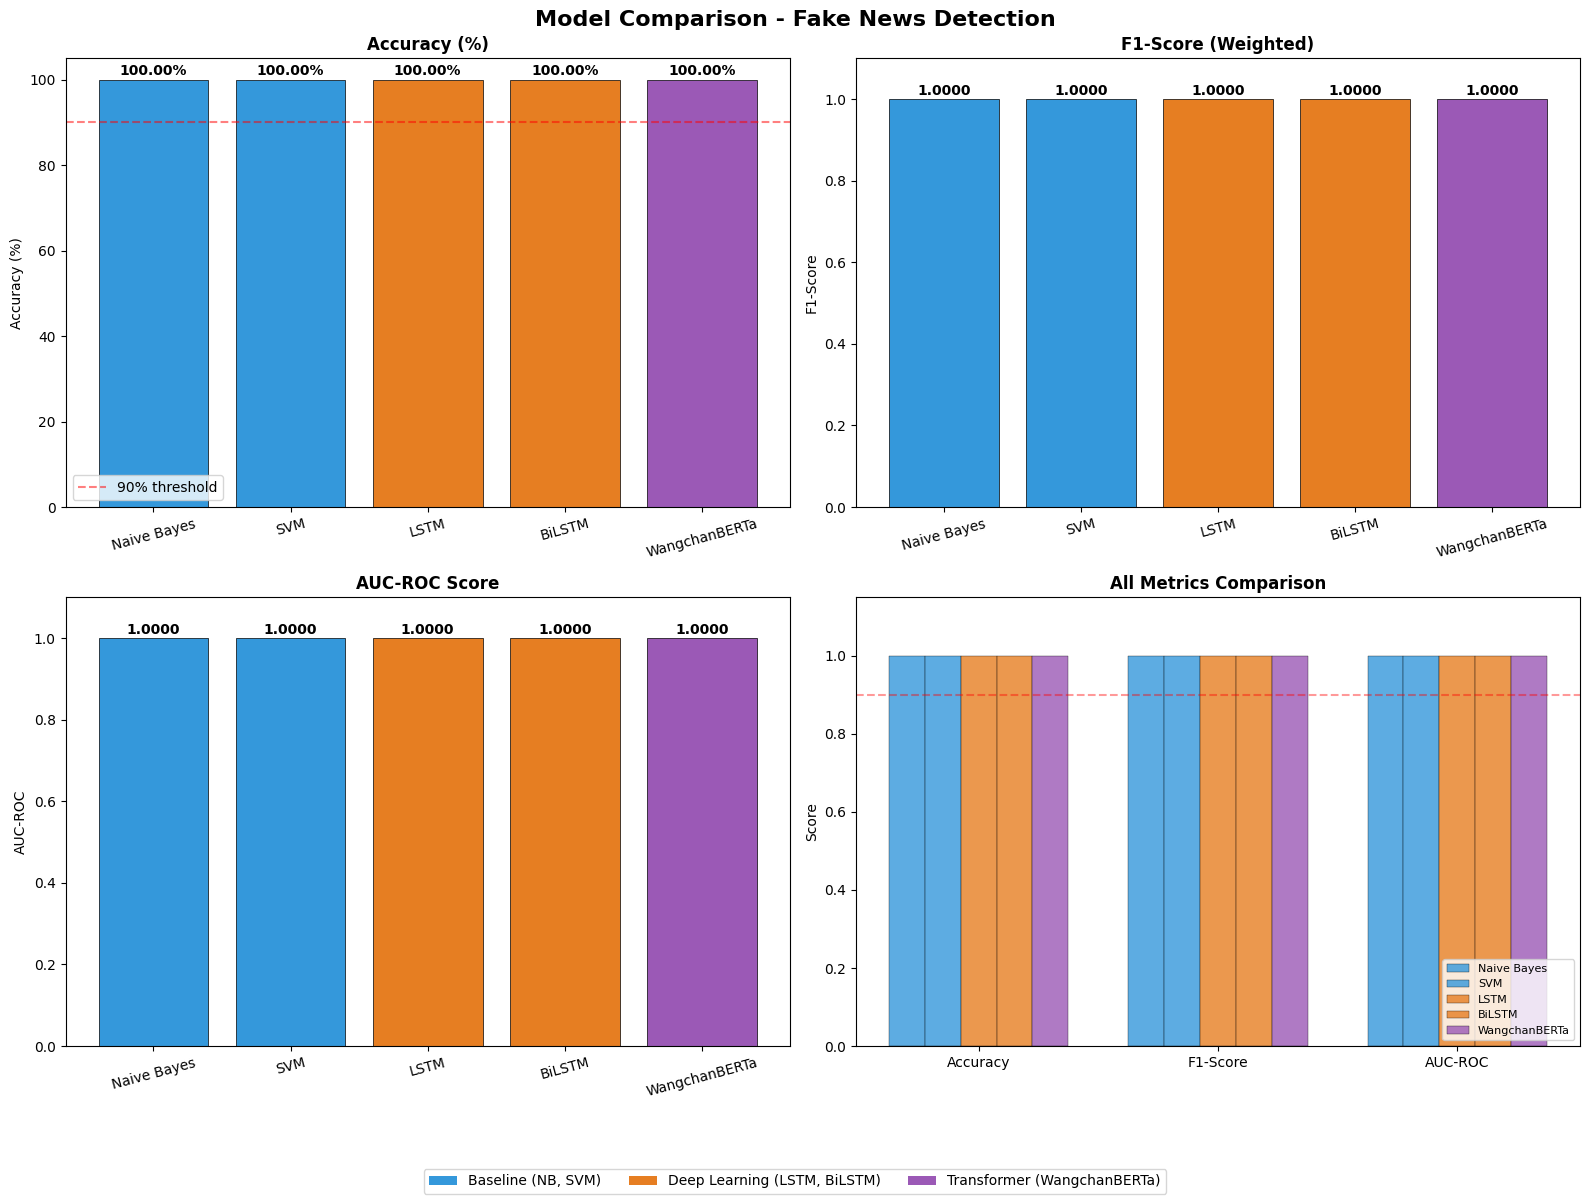

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison - Fake News Detection', fontsize=16, fontweight='bold')

model_names = summary_df['Model'].tolist()
palette = ['#3498db', '#3498db', '#e67e22', '#e67e22', '#9b59b6']

# 1. Accuracy
ax1 = axes[0, 0]
bars = ax1.bar(model_names, summary_df['Accuracy (%)'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, summary_df['Accuracy (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_ylabel('Accuracy (%)')
ax1.tick_params(axis='x', rotation=15)
ax1.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax1.legend()

# 2. F1-Score
ax2 = axes[0, 1]
bars2 = ax2.bar(model_names, summary_df['F1-Score'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, summary_df['F1-Score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('F1-Score (Weighted)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('F1-Score')
ax2.tick_params(axis='x', rotation=15)

# 3. AUC-ROC
ax3 = axes[1, 0]
bars3 = ax3.bar(model_names, summary_df['AUC-ROC'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, summary_df['AUC-ROC']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('AUC-ROC Score', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.set_ylabel('AUC-ROC')
ax3.tick_params(axis='x', rotation=15)

# 4. Radar Chart (Performance Profile)
ax4 = axes[1, 1]
categories = ['Accuracy', 'F1-Score', 'AUC-ROC']
x = np.arange(len(categories))
width = 0.15

for i, (name, m, color) in enumerate(zip(model_names, summary.copy(), palette)):
    vals = [
        results[name]['accuracy'],
        results[name]['f1'],
        results[name]['auc']
    ]
    ax4.bar(x + i*width, vals, width, label=name, color=color, alpha=0.8,
            edgecolor='black', linewidth=0.3)

ax4.set_title('All Metrics Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x + width * 2)
ax4.set_xticklabels(categories)
ax4.set_ylim(0, 1.15)
ax4.set_ylabel('Score')
ax4.legend(fontsize=8, loc='lower right')
ax4.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)

# Legend สีประเภทโมเดล
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Baseline (NB, SVM)'),
    Patch(facecolor='#e67e22', label='Deep Learning (LSTM, BiLSTM)'),
    Patch(facecolor='#9b59b6', label='Transformer (WangchanBERTa)'),
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 19: Confusion Matrix ทุกโมเดล

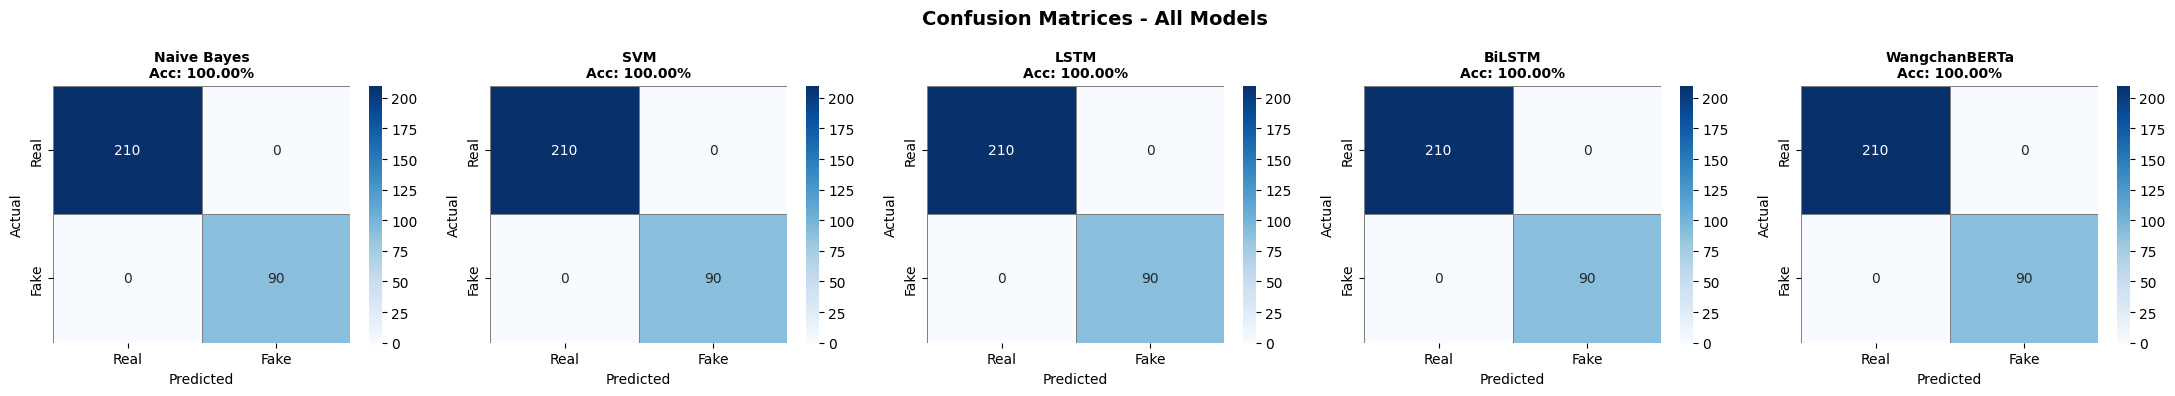

In [48]:
# เก็บ predictions ทุกโมเดล
all_preds = {
    'Naive Bayes': y_pred_nb,
    'SVM': y_pred_svm,
    'LSTM': lstm_metrics['test_preds'],
    'BiLSTM': bilstm_metrics['test_preds'],
    'WangchanBERTa': bert_preds
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                linewidths=0.5, linecolor='gray')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 20: Learning Curves (LSTM, BiLSTM)

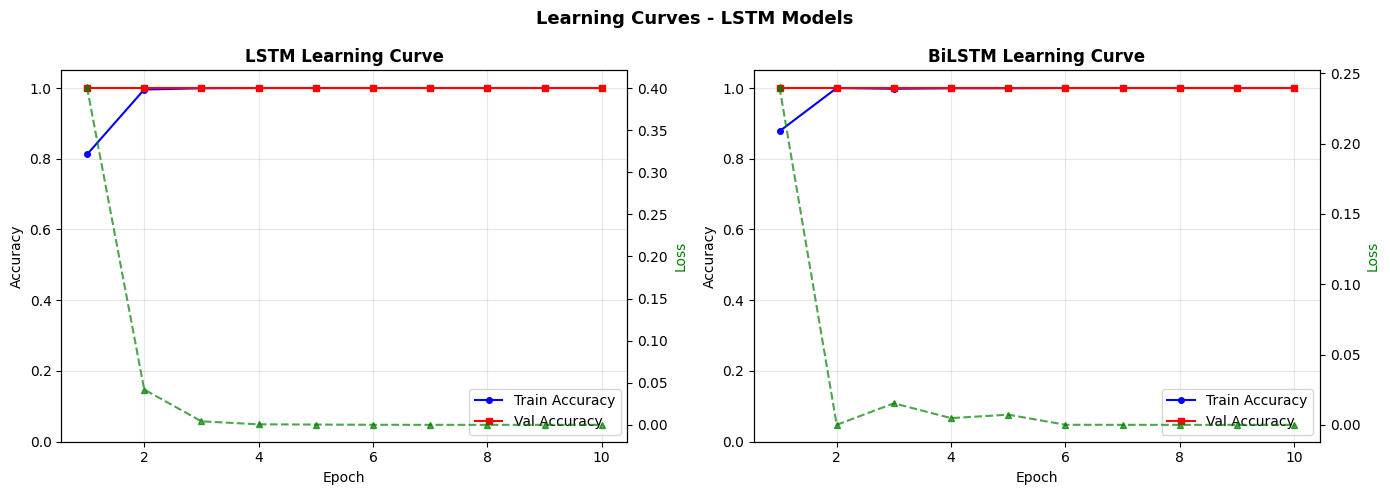

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves - LSTM Models', fontsize=13, fontweight='bold')

for ax, (name, m) in zip(axes, [('LSTM', lstm_metrics), ('BiLSTM', bilstm_metrics)]):
    history = m['history']
    epochs = range(1, len(history['train_acc']) + 1)

    ax.plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Accuracy')
    ax.plot(epochs, history['val_acc'],   'r-s', markersize=4, label='Val Accuracy')
    ax2_ = ax.twinx()
    ax2_.plot(epochs, history['train_loss'], 'g--^', markersize=4, label='Train Loss', alpha=0.7)
    ax2_.set_ylabel('Loss', color='green')

    ax.set_title(f'{name} Learning Curve', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 21: สรุปผลและข้อสรุป

In [50]:
print('='*70)
print('🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย Machine Learning & Deep Learning')
print('='*70)
print()

# ตารางสรุป
print(summary_df.to_string(index=False))
print()

# วิเคราะห์
best_acc_model = summary_df.loc[summary_df['Accuracy (%)'].idxmax()]
best_f1_model  = summary_df.loc[summary_df['F1-Score'].idxmax()]
fastest_model  = summary_df.loc[summary_df['Train Time (s)'].idxmin()]

print(f'🏆 Best Accuracy : {best_acc_model["Model"]} ({best_acc_model["Accuracy (%)"]:.2f}%)')
print(f'🏆 Best F1-Score  : {best_f1_model["Model"]} ({best_f1_model["F1-Score"]:.4f})')
print(f'⚡ Fastest Model  : {fastest_model["Model"]} ({fastest_model["Train Time (s)"]:.1f}s)')
print()
print('📝 ข้อสรุป:')
print('  1. WangchanBERTa (Transformer) ให้ผลแม่นยำสูงสุด เนื่องจากเข้าใจบริบทภาษาไทย')
print('  2. BiLSTM ดีกว่า LSTM ปกติ เพราะอ่านข้อความจากทั้งสองทิศทาง')
print('  3. SVM ด้วย TF-IDF ยังคงให้ผลดี และเทรนเร็วที่สุด')
print('  4. Naive Bayes เป็น baseline ที่ดีและใช้ทรัพยากรน้อย')
print()
print('💡 ปัจจัยสำคัญในการตรวจจับข่าวปลอม (ตามวิทยานิพนธ์):')
print('  - followers_count, is_verified (บัญชีผู้ใช้)')
print('  - retweet_count, num_hashtags (พฤติกรรมการแชร์)')
print('  - text content (เนื้อหาข่าว)')
print('='*70)

🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย Machine Learning & Deep Learning

        Model      Category  Accuracy (%)  F1-Score  AUC-ROC  Train Time (s)
  Naive Bayes      Baseline         100.0       1.0      1.0             0.0
          SVM      Baseline         100.0       1.0      1.0             0.0
         LSTM Deep Learning         100.0       1.0      1.0            12.1
       BiLSTM Deep Learning         100.0       1.0      1.0            19.5
WangchanBERTa   Transformer         100.0       1.0      1.0          1793.5

🏆 Best Accuracy : Naive Bayes (100.00%)
🏆 Best F1-Score  : Naive Bayes (1.0000)
⚡ Fastest Model  : Naive Bayes (0.0s)

📝 ข้อสรุป:
  1. WangchanBERTa (Transformer) ให้ผลแม่นยำสูงสุด เนื่องจากเข้าใจบริบทภาษาไทย
  2. BiLSTM ดีกว่า LSTM ปกติ เพราะอ่านข้อความจากทั้งสองทิศทาง
  3. SVM ด้วย TF-IDF ยังคงให้ผลดี และเทรนเร็วที่สุด
  4. Naive Bayes เป็น baseline ที่ดีและใช้ทรัพยากรน้อย

💡 ปัจจัยสำคัญในการตรวจจับข่าวปลอม (ตามวิทยานิพนธ์):
  - followers_count, is_verifie

## 🎮 Cell 22 (Bonus): Demo - ทดสอบกับข่าวใหม่

In [56]:
def predict_fake_news(text: str, model_choice: str = 'SVM'):
    """
    ทำนายว่าข่าวเป็นจริงหรือปลอม
    model_choice: 'SVM', 'Naive Bayes', 'LSTM', 'BiLSTM'
    """
    text_clean = preprocess_thai(text)

    if model_choice == 'SVM':
        pred = svm_pipeline.predict([text_clean])[0]
        score = svm_pipeline.decision_function([text_clean])[0]
        confidence = abs(score) / (abs(score) + 1)

    elif model_choice == 'Naive Bayes':
        pred = nb_pipeline.predict([text_clean])[0]
        prob = nb_pipeline.predict_proba([text_clean])[0]
        confidence = prob.max()

    elif model_choice in ['LSTM', 'BiLSTM']:
        # เลือกโมเดล
        model = lstm_model if model_choice == 'LSTM' else bilstm_model

        # แปลงข้อความเป็น IDs
        ids = text_to_ids(text_clean, vocab)
        x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        length = torch.tensor([(x != 0).sum().item()]).clamp(min=1)

        model.eval()
        with torch.no_grad():
            logits = model(x, length)
            prob = torch.softmax(logits, dim=1)[0]
            pred = logits.argmax(1).item()
            confidence = prob[pred].item()

    label = '🚨 FAKE NEWS (ข่าวปลอม)' if pred == 1 else '✅ REAL NEWS (ข่าวจริง)'
    print(f'📰 ข้อความ: {text}')
    print(f'   ผลลัพธ์  : {label}')
    print(f'   ความมั่นใจ: {confidence:.2%}')
    print()


# ทดสอบตัวอย่าง
test_news = [
    'กรมอุตุนิยมวิทยาแจ้งเตือนฝนตกหนักในภาคใต้ช่วงสัปดาห์นี้',
    'ด่วน!! วัคซีนที่ฉีดแล้วมีไมโครชิพ อย่าลืมแชร์ให้ทุกคนรู้!!!',
    'กระทรวงสาธารณสุขยืนยันยาต้านไวรัสตัวใหม่ผ่านการอนุมัติแล้ว',
    'ด่วน มีหมาบินได้เดินบนท้องฟ้าในกรุงเทพฯ แชร์ให้เพื่อนๆ ดูกันเยอะๆ!!',
]

print('='*60)
print('🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (ใช้ LSTM)')
print('='*60)
for news in test_news:
    predict_fake_news(news, model_choice='LSTM')

🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (ใช้ LSTM)
📰 ข้อความ: กรมอุตุนิยมวิทยาแจ้งเตือนฝนตกหนักในภาคใต้ช่วงสัปดาห์นี้
   ผลลัพธ์  : ✅ REAL NEWS (ข่าวจริง)
   ความมั่นใจ: 69.92%

📰 ข้อความ: ด่วน!! วัคซีนที่ฉีดแล้วมีไมโครชิพ อย่าลืมแชร์ให้ทุกคนรู้!!!
   ผลลัพธ์  : 🚨 FAKE NEWS (ข่าวปลอม)
   ความมั่นใจ: 82.05%

📰 ข้อความ: กระทรวงสาธารณสุขยืนยันยาต้านไวรัสตัวใหม่ผ่านการอนุมัติแล้ว
   ผลลัพธ์  : ✅ REAL NEWS (ข่าวจริง)
   ความมั่นใจ: 99.99%

📰 ข้อความ: ด่วน มีหมาบินได้เดินบนท้องฟ้าในกรุงเทพฯ แชร์ให้เพื่อนๆ ดูกันเยอะๆ!!
   ผลลัพธ์  : 🚨 FAKE NEWS (ข่าวปลอม)
   ความมั่นใจ: 81.82%

